# Healthcare Test Results Prediction
## Data Analytics & Machine Learning Project

**Dataset**: Synthetic Healthcare Dataset (Kaggle)

**Problem Type**: Multiclass Classification

**Target Variable**: Test Results (Normal / Abnormal / Inconclusive)

**Objective**: Predict the test outcome of a hospital patient based on demographic, clinical, and administrative features.


## Section 1 — Import Libraries

In [1]:
import os, warnings, json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler, OrdinalEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, HistGradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay, roc_auc_score
)

warnings.filterwarnings('ignore')
np.random.seed(42)
print('Libraries loaded successfully')

Libraries loaded successfully


## Section 2 — Load Dataset

In [2]:
df = pd.read_csv('../data/healthcare_dataset.csv')
print(f'Shape: {df.shape}')
df.head()

Shape: (55500, 15)


,Name,Age,Gender,Blood Type,Medical Condition,Date of Admission,Doctor,Hospital,Insurance Provider,Billing Amount,Room Number,Admission Type,Discharge Date,Medication,Test Results
0,Bobby JacksOn,30,Male,B-,Cancer,2024-01-31,Matthew Smith,Sons and Miller,Blue Cross,18856.281306,328,Urgent,2024-02-02,Paracetamol,Normal
1,LesLie TErRy,62,Male,A+,Obesity,2019-08-20,Samantha Davies,Kim Inc,Medicare,33643.327287,265,Emergency,2019-08-26,Ibuprofen,Inconclusive
2,DaNnY sMitH,76,Female,A-,Obesity,2022-09-22,Tiffany Mitchell,Cook PLC,Aetna,27955.096079,205,Emergency,2022-10-07,Aspirin,Normal
3,andrEw waTtS,28,Female,O+,Diabetes,2020-11-18,Kevin Wells,"Hernandez Rogers and Vang,",Medicare,37909.782410,450,Elective,2020-12-18,Ibuprofen,Abnormal
4,adrIENNE bEll,43,Female,AB+,Cancer,2022-09-19,Kathleen Hanna,White-White,Aetna,14238.317814,458,Urgent,2022-10-09,Penicillin,Abnormal


In [3]:
print('Columns:', df.columns.tolist())
print()
print(df.dtypes)

Columns: ['Name', 'Age', 'Gender', 'Blood Type', 'Medical Condition', 'Date of Admission', 'Doctor', 'Hospital', 'Insurance Provider', 'Billing Amount', 'Room Number', 'Admission Type', 'Discharge Date', 'Medication', 'Test Results']

Name                      str
Age                     int64
Gender                    str
Blood Type                str
Medical Condition         str
Date of Admission         str
Doctor                    str
Hospital                  str
Insurance Provider        str
Billing Amount        float64
Room Number             int64
Admission Type            str
Discharge Date            str
Medication                str
Test Results              str
dtype: object


In [4]:
df.describe(include='all')

,Name,Age,Gender,Blood Type,Medical Condition,Date of Admission,Doctor,Hospital,Insurance Provider,Billing Amount,Room Number,Admission Type,Discharge Date,Medication,Test Results
count,55500,55500.000000,55500,55500,55500,55500,55500,55500,55500,55500.000000,55500.000000,55500,55500,55500,55500
unique,49992,NaN,2,8,6,1827,40341,39876,5,NaN,NaN,3,1856,5,3
top,DAvId muNoZ,NaN,Male,A-,Arthritis,2024-03-16,Michael Smith,LLC Smith,Cigna,NaN,NaN,Elective,2020-03-15,Lipitor,Abnormal
freq,3,NaN,27774,6969,9308,50,27,44,11249,NaN,NaN,18655,53,11140,18627
mean,NaN,51.539459,NaN,NaN,NaN,NaN,NaN,NaN,NaN,25539.316097,301.134829,NaN,NaN,NaN,NaN
std,NaN,19.602454,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14211.454431,115.243069,NaN,NaN,NaN,NaN
min,NaN,13.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-2008.492140,101.000000,NaN,NaN,NaN,NaN
25%,NaN,35.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,13241.224652,202.000000,NaN,NaN,NaN,NaN
50%,NaN,52.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,25538.069376,302.000000,NaN,NaN,NaN,NaN
75%,NaN,68.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,37820.508436,401.000000,NaN,NaN,NaN,NaN


## Section 3 — Data Quality Analysis

In [5]:
print('Missing Values:')
print(df.isnull().sum())
print()
print(f'Duplicate rows: {df.duplicated().sum()}')
print(f'Negative Billing Amounts: {(df["Billing Amount"] < 0).sum()}')

Missing Values:
Name                  0
Age                   0
Gender                0
Blood Type            0
Medical Condition     0
Date of Admission     0
Doctor                0
Hospital              0
Insurance Provider    0
Billing Amount        0
Room Number           0
Admission Type        0
Discharge Date        0
Medication            0
Test Results          0
dtype: int64

Duplicate rows: 534
Negative Billing Amounts: 108


In [6]:
df = df.drop_duplicates()
print(f'After removing duplicates: {df.shape[0]} rows')

After removing duplicates: 54966 rows


## Section 4 — Feature Engineering

In [7]:
df['Date of Admission'] = pd.to_datetime(df['Date of Admission'])
df['Discharge Date']    = pd.to_datetime(df['Discharge Date'])
df['Length of Stay']    = (df['Discharge Date'] - df['Date of Admission']).dt.days
df['Admission Year']    = df['Date of Admission'].dt.year
df['Admission Month']   = df['Date of Admission'].dt.month
df['Admission DayOfWeek'] = df['Date of Admission'].dt.dayofweek
print('New features created: Length of Stay, Admission Year, Admission Month, Admission DayOfWeek')
df[['Length of Stay','Admission Year','Admission Month','Admission DayOfWeek']].describe()

New features created: Length of Stay, Admission Year, Admission Month, Admission DayOfWeek


,Length of Stay,Admission Year,Admission Month,Admission DayOfWeek
count,54966.000000,54966.000000,54966.000000,54966.000000
mean,15.499290,2021.336499,6.528709,2.999454
std,8.661471,1.497444,3.437880,1.997497
min,1.000000,2019.000000,1.000000,0.000000
25%,8.000000,2020.000000,4.000000,1.000000
50%,15.000000,2021.000000,7.000000,3.000000
75%,23.000000,2023.000000,9.000000,5.000000
max,30.000000,2024.000000,12.000000,6.000000


## Section 5 — Exploratory Data Analysis

Target Distribution:
Test Results
Abnormal        18437
Normal          18331
Inconclusive    18198
Name: count, dtype: int64


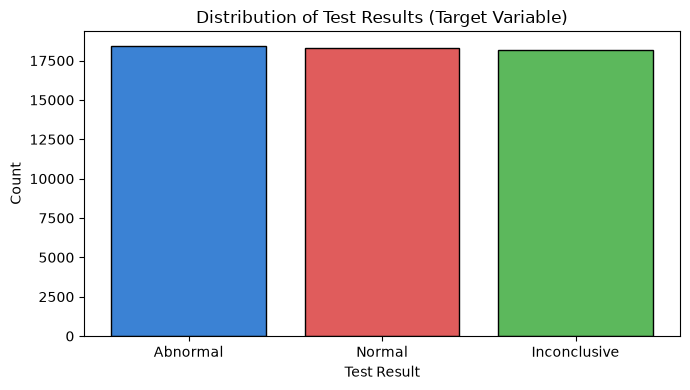

In [8]:
print('Target Distribution:')
print(df['Test Results'].value_counts())
fig, ax = plt.subplots(figsize=(7,4))
vals = df['Test Results'].value_counts()
ax.bar(vals.index, vals.values, color=['#3b82d4','#e05c5c','#5cb85c'], edgecolor='black')
ax.set_title('Distribution of Test Results (Target Variable)')
ax.set_xlabel('Test Result'); ax.set_ylabel('Count')
plt.tight_layout(); plt.show()

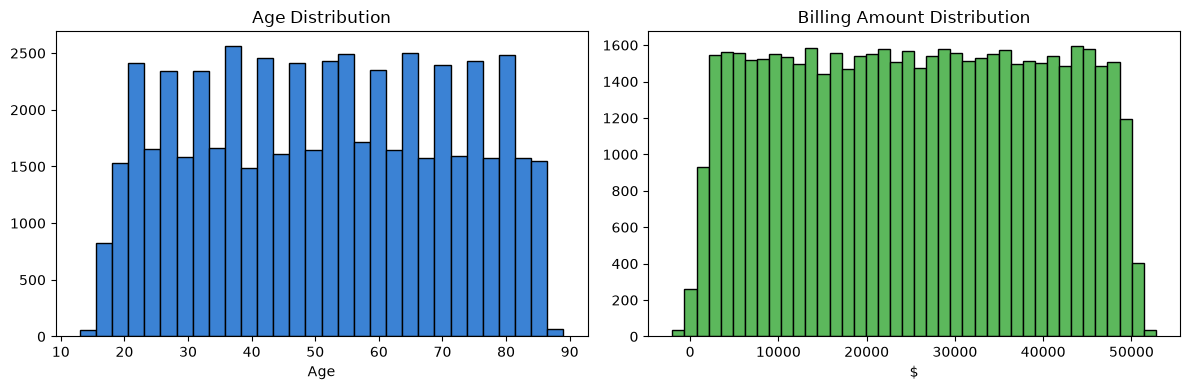

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12,4))
axes[0].hist(df['Age'], bins=30, color='#3b82d4', edgecolor='black')
axes[0].set_title('Age Distribution'); axes[0].set_xlabel('Age')
axes[1].hist(df['Billing Amount'], bins=40, color='#5cb85c', edgecolor='black')
axes[1].set_title('Billing Amount Distribution'); axes[1].set_xlabel('$')
plt.tight_layout(); plt.show()

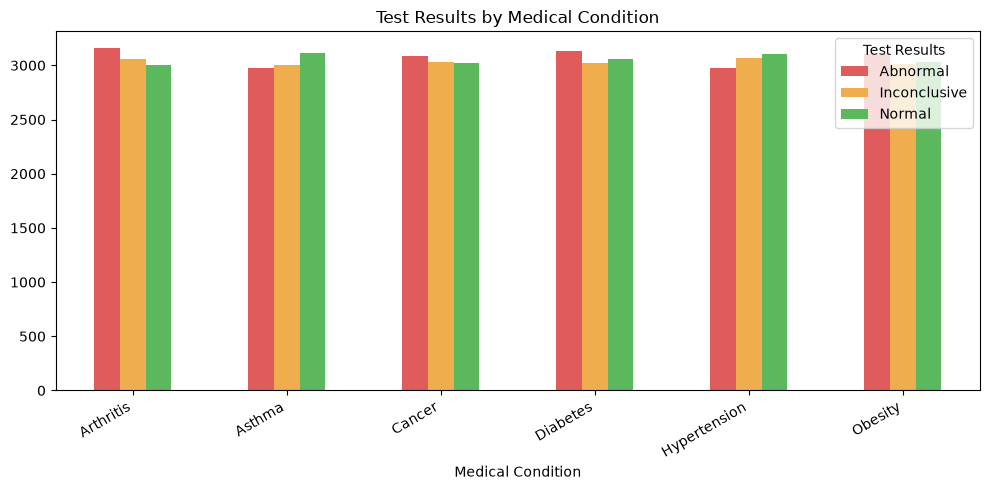

In [10]:
ct = pd.crosstab(df['Medical Condition'], df['Test Results'])
ct.plot(kind='bar', figsize=(10,5), color=['#e05c5c','#f0ad4e','#5cb85c'])
plt.title('Test Results by Medical Condition')
plt.xticks(rotation=30, ha='right'); plt.tight_layout(); plt.show()

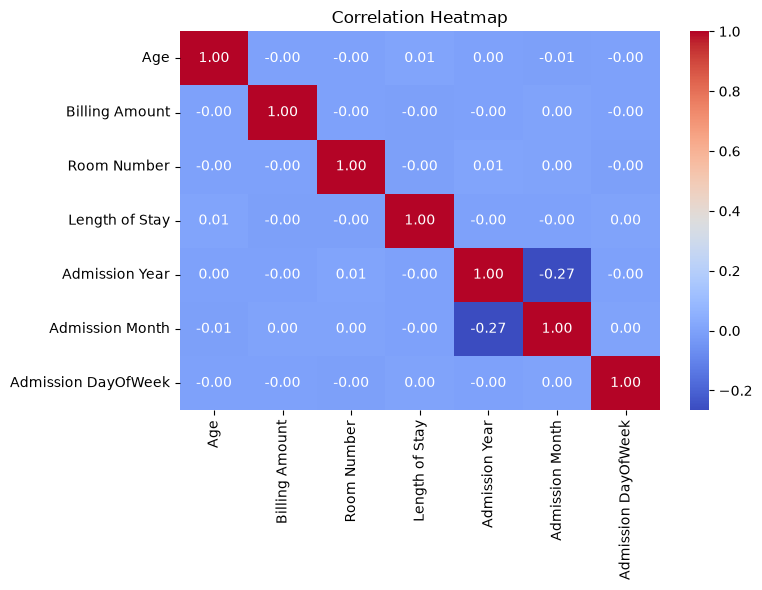

In [11]:
num_cols = ['Age','Billing Amount','Room Number','Length of Stay','Admission Year','Admission Month','Admission DayOfWeek']
fig, ax = plt.subplots(figsize=(8,6))
sns.heatmap(df[num_cols].corr(), annot=True, fmt='.2f', cmap='coolwarm', ax=ax)
ax.set_title('Correlation Heatmap')
plt.tight_layout(); plt.show()

## Section 6 — Data Preprocessing & Pipeline

In [12]:
TARGET = 'Test Results'
DROP_COLS = ['Name','Doctor','Hospital','Date of Admission','Discharge Date']
X = df.drop(columns=DROP_COLS + [TARGET])
y = df[TARGET]

numerical_features   = ['Age','Billing Amount','Room Number','Length of Stay',
                         'Admission Year','Admission Month','Admission DayOfWeek']
categorical_features = ['Gender','Blood Type','Medical Condition','Insurance Provider',
                         'Admission Type','Medication']

numerical_pipeline   = Pipeline([('imputer', SimpleImputer(strategy='median')),
                                   ('scaler',  StandardScaler())])
categorical_pipeline = Pipeline([('imputer', SimpleImputer(strategy='most_frequent')),
                                   ('encoder', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1))])
preprocessor = ColumnTransformer(transformers=[
    ('num', numerical_pipeline,   numerical_features),
    ('cat', categorical_pipeline, categorical_features)
])
print('Preprocessor pipeline ready')

Preprocessor pipeline ready


## Section 7 — Train / Test Split

In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)
print(f'Train: {X_train.shape[0]} | Test: {X_test.shape[0]}')

Train: 43972 | Test: 10994


## Section 8 — Train Multiple Models

In [14]:
models = {
    'Logistic Regression':  LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest':        RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    'Gradient Boosting':    GradientBoostingClassifier(n_estimators=100, random_state=42),
    'HistGradientBoosting': HistGradientBoostingClassifier(max_iter=100, random_state=42),
}

results = []
trained_pipelines = {}

for name, clf in models.items():
    print(f'Training: {name} ...')
    pipe = Pipeline([('preprocessor', preprocessor), ('classifier', clf)])
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)
    acc  = accuracy_score(y_test, y_pred)
    f1   = f1_score(y_test, y_pred, average='weighted', zero_division=0)
    results.append({'Model': name, 'Accuracy': round(acc,4), 'F1': round(f1,4)})
    trained_pipelines[name] = pipe
    print(f'  Accuracy={acc:.4f} | F1={f1:.4f}')

Training: Logistic Regression ...
  Accuracy=0.3326 | F1=0.3304
Training: Random Forest ...
  Accuracy=0.4263 | F1=0.4261
Training: Gradient Boosting ...
  Accuracy=0.3333 | F1=0.3325
Training: HistGradientBoosting ...
  Accuracy=0.3413 | F1=0.3389


## Section 9 — Model Comparison

               Model  Accuracy     F1
       Random Forest    0.4263 0.4261
HistGradientBoosting    0.3413 0.3389
   Gradient Boosting    0.3333 0.3325
 Logistic Regression    0.3326 0.3304


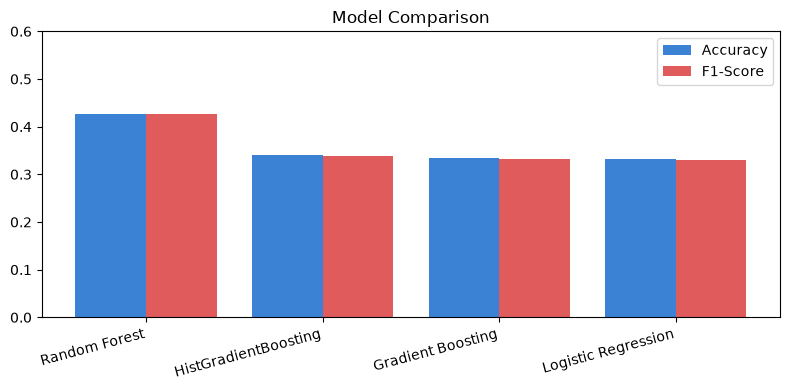

In [15]:
results_df = pd.DataFrame(results).sort_values('F1', ascending=False)
print(results_df.to_string(index=False))

fig, ax = plt.subplots(figsize=(8,4))
x = range(len(results_df))
ax.bar([i-0.2 for i in x], results_df['Accuracy'], 0.4, label='Accuracy', color='#3b82d4')
ax.bar([i+0.2 for i in x], results_df['F1'], 0.4, label='F1-Score', color='#e05c5c')
ax.set_xticks(list(x)); ax.set_xticklabels(results_df['Model'], rotation=15, ha='right')
ax.set_ylim(0,0.6); ax.set_title('Model Comparison'); ax.legend()
plt.tight_layout(); plt.show()

## Section 10 — Best Model & Evaluation

Best Model: Random Forest
              precision    recall  f1-score   support

    Abnormal       0.42      0.46      0.44      3688
Inconclusive       0.42      0.41      0.41      3640
      Normal       0.44      0.41      0.43      3666

    accuracy                           0.43     10994
   macro avg       0.43      0.43      0.43     10994
weighted avg       0.43      0.43      0.43     10994



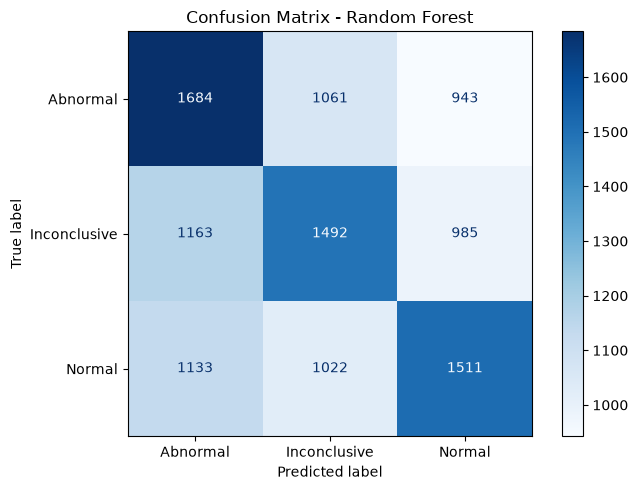

In [16]:
best_name = results_df.iloc[0]['Model']
best_pipe = trained_pipelines[best_name]
y_pred_best = best_pipe.predict(X_test)
print(f'Best Model: {best_name}')
print(classification_report(y_test, y_pred_best))

cm = confusion_matrix(y_test, y_pred_best, labels=best_pipe.classes_)
fig, ax = plt.subplots(figsize=(7,5))
ConfusionMatrixDisplay(cm, display_labels=best_pipe.classes_).plot(ax=ax, cmap='Blues')
ax.set_title(f'Confusion Matrix - {best_name}')
plt.tight_layout(); plt.show()

## Section 11 — Feature Importance

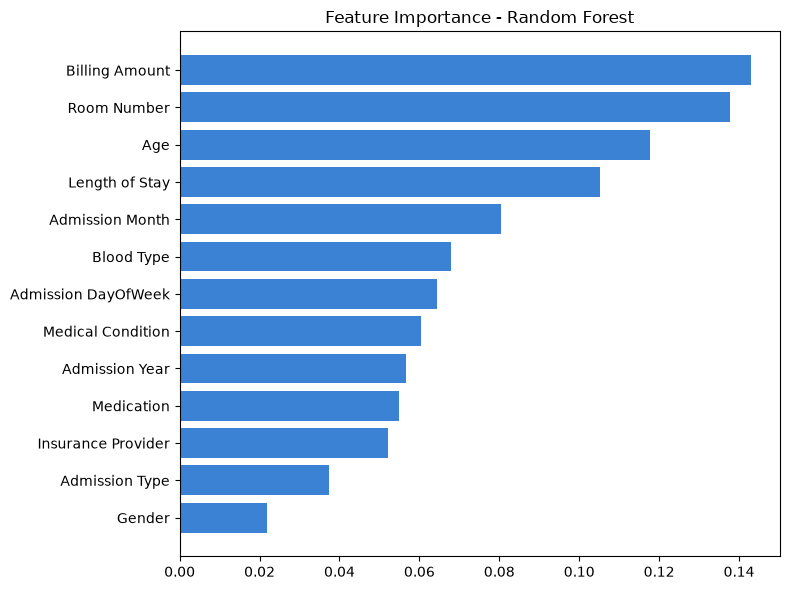

In [17]:
clf_step = best_pipe.named_steps['classifier']
if hasattr(clf_step, 'feature_importances_'):
    all_feat_names = numerical_features + categorical_features
    fi_df = pd.DataFrame({'Feature': all_feat_names, 'Importance': clf_step.feature_importances_})
    fi_df = fi_df.sort_values('Importance')
    fig, ax = plt.subplots(figsize=(8,6))
    ax.barh(fi_df['Feature'], fi_df['Importance'], color='#3b82d4')
    ax.set_title(f'Feature Importance - {best_name}')
    plt.tight_layout(); plt.show()
else:
    print('Feature importance not available for this model')

## Section 12 — Save & Test Model

In [18]:
joblib.dump(best_pipe, '../model/trained_model.pkl')
print('Model saved: ../model/trained_model.pkl')

loaded = joblib.load('../model/trained_model.pkl')
sample = X_test.iloc[:3].copy()
preds  = loaded.predict(sample)
print('Sample predictions:', preds)
print('Actual labels:     ', y_test.iloc[:3].values)

Model saved: ../model/trained_model.pkl
Sample predictions: ['Normal' 'Inconclusive' 'Abnormal']
Actual labels:      <ArrowStringArray>
['Normal', 'Abnormal', 'Normal']
Length: 3, dtype: str
